In [1]:
# === Setup: Install necessary libraries ===
!pip install netcdf4 geopandas cartopy windrose shapely xarray -q

print("Libraries installed/updated.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 23.5 MB/s eta 0:00:00
Libraries installed/updated.


In [2]:
# === Import Libraries ===
import xarray as xr
import pandas as pd
import geopandas as gpd
import numpy as np
from shapely.geometry import Point, box
from scipy.special import gamma
from scipy.stats import weibull_min

# Plotting libraries
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from windrose import WindroseAxes

# Colab specific
from google.colab import drive

# Optional: Suppress warnings
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

print("Libraries imported.")

Libraries imported.


In [3]:
# === Mount Google Drive ===
try:
    drive.mount('/content/drive')
    print("Google Drive mounted successfully.")
except Exception as e:
    print(f"Error mounting Google Drive: {e}")

Mounted at /content/drive
Google Drive mounted successfully.


In [4]:
# === Configuration ===

# --- File Paths ---
NETCDF_FILE_PATH = '/content/drive/MyDrive/Paper/Copy of 2024.nc'
EEZ_FILE_PATH = "/content/drive/MyDrive/Paper/World_EEZ_v12_20231025_gpkg/eez_v12.gpkg"
EEZ_COUNTRY_COLUMN = "TERRITORY1" # Column name in EEZ file identifying the country

# --- Analysis Parameters ---
CASPIAN_COUNTRIES = ["Azerbaijan", "Iran", "Kazakhstan", "Russia", "Turkmenistan"]
# Parameters for selecting "Windiest" locations (P90 Method @ 10m)
PERCENTILE_VALUE = 0.90       # Percentile speed to calculate for each location
RANKING_PERCENTILE = 90     # Select locations whose P-value speed is in the top %

# --- Projection ---
CASPIAN_LAEA_PROJ4 = "+proj=laea +lat_0=42 +lon_0=51 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"

# --- Plotting ---
MAP_EXTENT = (45, 57, 34, 49) # MinLon, MaxLon, MinLat, MaxLat for Caspian focus
COUNTRY_COLORS = plt.cm.get_cmap('tab10', len(CASPIAN_COUNTRIES))
COLOR_10M = 'lightcoral' # Weibull hist color (Primary color for this notebook)
CMAP_10M = plt.cm.coolwarm # Wind rose colormap (Primary cmap for this notebook)
EXPORT_TO_SHEETS = False # Set to True to enable optional export at the end
SPREADSHEET_NAME = "CaspianWindAnalysis_Results_10m" # Sheet name for 10m results

print("Configuration set.")

Configuration set.


<ipython-input-4-4105f5754435>:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  COUNTRY_COLORS = plt.cm.get_cmap('tab10', len(CASPIAN_COUNTRIES))


In [5]:
# === Load and Inspect NetCDF Data ===
df = None # Initialize df to None
try:
    print(f"Loading NetCDF dataset: {NETCDF_FILE_PATH}")
    ds = xr.open_dataset(NETCDF_FILE_PATH)
    print("NetCDF dataset loaded successfully.")
    print("\nDataset Preview:")
    print(ds)

    print("\nVariables and Units:")
    for var in ds.variables:
        units = ds[var].attrs.get('units', 'N/A')
        print(f"- {var}: {units}")

    print("\nConverting to Pandas DataFrame...")
    df = ds.to_dataframe().reset_index()
    ds.close() # Close file after converting
    print("NetCDF dataset closed.")

    print(f"\nDataFrame shape: {df.shape}")
    print("DataFrame head:")
    print(df.head())

    # Check time dimension
    if 'time' in df.columns:
        print(f"\nTime range: {df['time'].min()} to {df['time'].max()}")
        print(f"Number of unique time steps: {df['time'].nunique()}")
    else:
        print("\nWarning: 'time' column not found.")

    # Check required columns for 10m analysis
    required_components = ['u10', 'v10', 'longitude', 'latitude'] # Check for 10m components
    missing_cols = [col for col in required_components if col not in df.columns]
    if missing_cols:
         raise ValueError(f"DataFrame is missing essential 10m columns: {missing_cols}")
    else:
        print("\nRequired 10m wind component and coordinate columns found.")

except FileNotFoundError:
    print(f"Error: NetCDF file not found at {NETCDF_FILE_PATH}")
except Exception as e:
    print(f"An error occurred during NetCDF loading or processing: {e}")

Loading NetCDF dataset: /content/drive/MyDrive/Paper/Copy of 2024.nc
NetCDF dataset loaded successfully.

Dataset Preview:
<xarray.Dataset> Size: 283MB
Dimensions:     (valid_time: 8784, latitude: 49, longitude: 41)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 70kB 2024-01-01 ... 2024-12-31T23...
  * latitude    (latitude) float64 392B 48.0 47.75 47.5 ... 36.5 36.25 36.0
  * longitude   (longitude) float64 328B 46.0 46.25 46.5 ... 55.5 55.75 56.0
    expver      (valid_time) <U4 141kB ...
Data variables:
    u10         (valid_time, latitude, longitude) float32 71MB ...
    v10         (valid_time, latitude, longitude) float32 71MB ...
    u100        (valid_time, latitude, longitude) float32 71MB ...
    v100        (valid_time, latitude, longitude) float32 71MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:        

Loading EEZ GeoPackage: /content/drive/MyDrive/Paper/World_EEZ_v12_20231025_gpkg/eez_v12.gpkg
EEZ GeoPackage loaded successfully. Found 285 features.
Filtered and processed EEZ data for 5 Caspian countries.
     TERRITORY1                                           geometry  MRGID  \
0    Azerbaijan  POLYGON ((51.45665 41.22277, 51.52615 41.13417...  26524   
1          Iran  MULTIPOLYGON (((55.71521 26.88127, 55.71751 26...   8469   
2    Kazakhstan  POLYGON ((53.05601 45.75973, 53.05509 45.7544,...  26522   
3        Russia  MULTIPOLYGON (((47.56522 43.6592, 47.548 43.61...   5690   
4  Turkmenistan  MULTIPOLYGON (((52.44714 41.76157, 52.44981 41...  26523   

                               GEONAME  MRGID_TER1 POL_TYPE  MRGID_SOV1  \
0  Azerbaijani Exclusive Economic Zone      2134.0    200NM        2134   
1      Iranian Exclusive Economic Zone      2126.0    200NM        2126   
2       Kazakh Exclusive Economic Zone      2119.0    200NM        2119   
3      Russian Exclusive Econo

/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


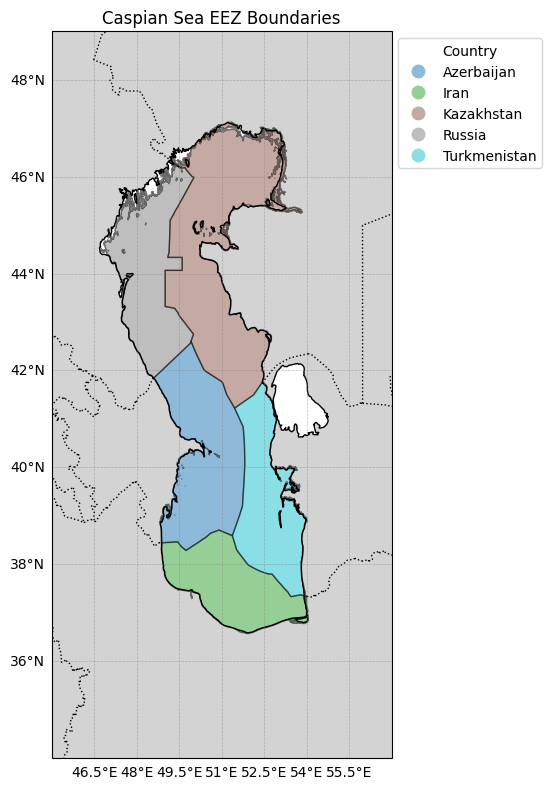

In [6]:
# === Load and Prepare EEZ Data ===
eez_caspian = None # Initialize to None
try:
    print(f"Loading EEZ GeoPackage: {EEZ_FILE_PATH}")
    eez_full = gpd.read_file(EEZ_FILE_PATH)
    print(f"EEZ GeoPackage loaded successfully. Found {len(eez_full)} features.")

    eez_caspian = eez_full[eez_full[EEZ_COUNTRY_COLUMN].isin(CASPIAN_COUNTRIES)].copy()
    eez_caspian = eez_caspian[eez_caspian.is_valid]
    eez_caspian = eez_caspian.dissolve(by=EEZ_COUNTRY_COLUMN).reset_index()
    print(f"Filtered and processed EEZ data for {len(eez_caspian)} Caspian countries.")
    print(eez_caspian.head())

    # --- Visualize EEZ Boundaries ---
    print("\nPlotting Caspian EEZ boundaries...")
    fig_eez, ax_eez = plt.subplots(1, 1, figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})
    ax_eez.set_extent(MAP_EXTENT, crs=ccrs.PlateCarree())
    ax_eez.add_feature(cfeature.LAND, facecolor='lightgray')
    ax_eez.add_feature(cfeature.COASTLINE)
    ax_eez.add_feature(cfeature.BORDERS, linestyle=':')
    eez_caspian.plot(ax=ax_eez, column=EEZ_COUNTRY_COLUMN, edgecolor='black', alpha=0.5, legend=True,
                     legend_kwds={'title': "Country", 'loc': 'upper left', 'bbox_to_anchor': (1, 1)})
    gl_eez = ax_eez.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl_eez.top_labels = False; gl_eez.right_labels = False
    ax_eez.set_title("Caspian Sea EEZ Boundaries")
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()

except FileNotFoundError:
    print(f"Error: EEZ file not found at {EEZ_FILE_PATH}")
except Exception as e:
    print(f"An error occurred during EEZ processing: {e}")

Performing spatial join to assign territory...
Found 2009 unique coordinate pairs.
Territory assigned to main DataFrame 'df'.

Territory Assignment Summary:
- Rows with territory assigned: 5735952 (32.5%)
- Rows without territory: 11911104 (67.5%)

Plotting assigned vs unassigned points...


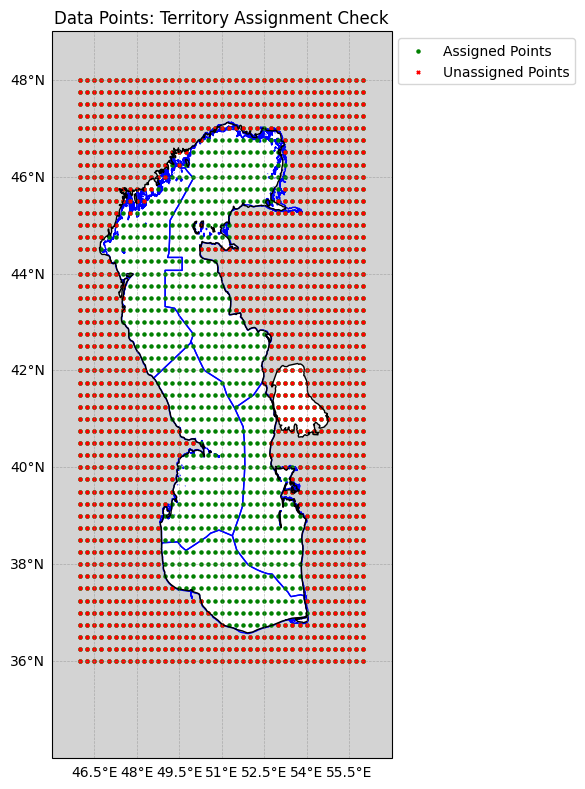

In [7]:
# === Assign Territory to Data Points ===
# (This step is identical regardless of 10m/100m focus)
if df is not None and eez_caspian is not None:
    if 'territory' in df.columns and df['territory'].notna().any():
        print("Territory column already exists and contains values. Skipping re-assignment.")
        proceed_assignment = False
    else:
        proceed_assignment = True

    if proceed_assignment:
        print("Performing spatial join to assign territory...")
        try:
            unique_coords_df = df[['longitude', 'latitude']].dropna().drop_duplicates()
            print(f"Found {len(unique_coords_df)} unique coordinate pairs.")
            geometry = gpd.points_from_xy(unique_coords_df['longitude'], unique_coords_df['latitude'])
            unique_points_gdf = gpd.GeoDataFrame(unique_coords_df, geometry=geometry, crs="EPSG:4326")

            if unique_points_gdf.crs != eez_caspian.crs:
                 eez_caspian = eez_caspian.to_crs(unique_points_gdf.crs)
            points_with_territory = gpd.sjoin(unique_points_gdf, eez_caspian[[EEZ_COUNTRY_COLUMN, 'geometry']],
                                              how="left", predicate="within")
            points_with_territory = points_with_territory[~points_with_territory.index.duplicated(keep='first')]

            territory_map_data = points_with_territory[[EEZ_COUNTRY_COLUMN]]
            unique_coords_df_with_territory = unique_coords_df.join(territory_map_data, how='left')
            territory_mapping_dict = unique_coords_df_with_territory.set_index(['longitude', 'latitude'])[EEZ_COUNTRY_COLUMN].to_dict()

            df_index_tuples = list(zip(df['longitude'], df['latitude']))
            df['territory'] = pd.Series(df_index_tuples).map(territory_mapping_dict)
            print("Territory assigned to main DataFrame 'df'.")

            assigned_count = df['territory'].notna().sum(); unassigned_count = df['territory'].isna().sum(); total_rows = len(df)
            print(f"\nTerritory Assignment Summary:")
            print(f"- Rows with territory assigned: {assigned_count} ({assigned_count/total_rows:.1%})")
            print(f"- Rows without territory: {unassigned_count} ({unassigned_count/total_rows:.1%})")

            # Optional Visualization Check
            print("\nPlotting assigned vs unassigned points...")
            null_territory_points = df[df['territory'].isna()][['longitude', 'latitude']].drop_duplicates()
            non_null_territory_points_gdf = unique_points_gdf[unique_points_gdf.index.isin(points_with_territory.index)]
            fig_assign, ax_assign = plt.subplots(1, 1, figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})
            ax_assign.set_extent(MAP_EXTENT, crs=ccrs.PlateCarree()); ax_assign.add_feature(cfeature.LAND, facecolor='lightgray'); ax_assign.add_feature(cfeature.COASTLINE)
            eez_caspian.plot(ax=ax_assign, edgecolor='blue', facecolor='none', linewidth=1, label='Caspian EEZs')
            if not non_null_territory_points_gdf.empty: ax_assign.scatter(non_null_territory_points_gdf['longitude'], non_null_territory_points_gdf['latitude'], color='green', s=5, marker='o', label='Assigned Points', transform=ccrs.Geodetic())
            if not null_territory_points.empty: ax_assign.scatter(null_territory_points['longitude'], null_territory_points['latitude'], color='red', s=5, marker='x', label='Unassigned Points', transform=ccrs.Geodetic())
            gl_assign = ax_assign.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
            gl_assign.top_labels = False; gl_assign.right_labels = False; ax_assign.set_title("Data Points: Territory Assignment Check"); ax_assign.legend(loc='upper left', bbox_to_anchor=(1, 1))
            plt.tight_layout(rect=[0, 0, 0.85, 1]); plt.show()

        except Exception as e:
            print(f"An error occurred during territory assignment: {e}")
else:
    print("Error: Prerequisite 'df' or 'eez_caspian' not available. Skipping territory assignment.")

In [8]:
# === Calculate Instantaneous Speed (10m) ===
if df is not None:
    print("Calculating instantaneous speeds at 10m...")
    if 'u10' in df.columns and 'v10' in df.columns:
        # Calculate or recalculate 'instant_speed_10'
        df['instant_speed_10'] = np.sqrt(df['u10']**2 + df['v10']**2)
        print("Calculated/Updated 'instant_speed_10'.")
        print(df[['instant_speed_10']].describe())
    else:
        # If components are missing, but speed might exist from previous runs
        if 'instant_speed_10' in df.columns:
             print("Using existing 'instant_speed_10' column.")
             print(df[['instant_speed_10']].describe())
        else:
             # Critical error for this notebook if 10m speed can't be obtained
             raise ValueError("Error: u10/v10 columns missing, cannot calculate 10m speed.")
else:
    print("Error: DataFrame 'df' not available. Cannot calculate speeds.")

Calculating instantaneous speeds at 10m...
Calculated/Updated 'instant_speed_10'.
       instant_speed_10
count      1.764706e+07
mean       4.187091e+00
std        2.575184e+00
min        1.041629e-03
25%        2.131733e+00
50%        3.732748e+00
75%        5.784673e+00
max        2.105003e+01


In [9]:
# === Define Analysis Parameters & Calculate Grid Resolution ===

# --- Analysis Parameters ---
print(f"Using PERCENTILE_VALUE = {PERCENTILE_VALUE}")
print(f"Using RANKING_PERCENTILE = {RANKING_PERCENTILE}")

# --- Grid Resolution ---
delta_lat = 0
delta_lon = 0
if df is not None:
    try:
        unique_latitudes = np.unique(df['latitude'].dropna())
        unique_longitudes = np.unique(df['longitude'].dropna())
        lat_diffs = np.diff(unique_latitudes)
        lon_diffs = np.diff(unique_longitudes)
        if len(lat_diffs) > 0: delta_lat = np.median(lat_diffs)
        if len(lon_diffs) > 0: delta_lon = np.median(lon_diffs)
        print(f"Grid Resolution: dLat ~ {delta_lat:.4f} deg, dLon ~ {delta_lon:.4f} deg")
        if delta_lat <= 0 or delta_lon <= 0:
            print("Warning: Could not determine valid grid resolution.")
    except Exception as e:
        print(f"Error calculating grid resolution: {e}")
else:
    print("Error: DataFrame 'df' not available. Cannot calculate grid resolution.")

Using PERCENTILE_VALUE = 0.9
Using RANKING_PERCENTILE = 90
Grid Resolution: dLat ~ 0.2500 deg, dLon ~ 0.2500 deg


In [10]:
# === Identify Windiest Locations (10m P90 Method, Clipped) ===

results_pXX_clipped_10m = {}
best_area_geometries_pXX_clipped_10m = {}

if df is not None and eez_caspian is not None and delta_lat > 0 and delta_lon > 0:
    # --- Step 1: Calculate P90 Speed per Location (10m) ---
    print(f"\nCalculating P{int(PERCENTILE_VALUE*100)} instantaneous speed at 10m per location...")
    if 'instant_speed_10' not in df.columns:
        print("Error: 'instant_speed_10' column required but not found.")
    else:
        df_agg_10 = df.dropna(subset=['territory', 'instant_speed_10'])
        location_pXX_df_10m = df_agg_10.groupby(['longitude', 'latitude', 'territory'])['instant_speed_10'].quantile(PERCENTILE_VALUE).reset_index()
        pXX_col_name_10m = f'p{int(PERCENTILE_VALUE*100)}_speed_10'
        location_pXX_df_10m = location_pXX_df_10m.rename(columns={'instant_speed_10': pXX_col_name_10m})
        print(f"Calculated P{int(PERCENTILE_VALUE*100)} speed (10m) for {len(location_pXX_df_10m)} unique locations.")

        # --- Step 2: Calculate Best Area per Country (10m, Clipping Polygons) ---
        for country in CASPIAN_COUNTRIES:
            print(f"\nProcessing {country} - 10m...")
            calculated_area_sq_km = 0.0
            selected_coordinates = []
            clipped_gdf_for_plot = None

            df_country_pXX_10m = location_pXX_df_10m[location_pXX_df_10m['territory'] == country].copy()

            if not df_country_pXX_10m.empty and pXX_col_name_10m in df_country_pXX_10m.columns and not df_country_pXX_10m[pXX_col_name_10m].isnull().all():
                ranking_threshold_value = np.percentile(df_country_pXX_10m[pXX_col_name_10m].dropna(), RANKING_PERCENTILE)
                print(f"  {RANKING_PERCENTILE}th percentile threshold of P{int(PERCENTILE_VALUE*100)} speeds (10m): {ranking_threshold_value:.2f} m/s")

                best_locations_df_10m = df_country_pXX_10m[df_country_pXX_10m[pXX_col_name_10m] >= ranking_threshold_value].copy()
                num_best_locations = len(best_locations_df_10m)
                print(f"  Found {num_best_locations} unique locations in top {100-RANKING_PERCENTILE}% based on P{int(PERCENTILE_VALUE*100)} speed (10m).")

                if num_best_locations > 0:
                    selected_coordinates = list(zip(best_locations_df_10m['longitude'], best_locations_df_10m['latitude']))
                    try:
                        geometries = [box(r['longitude'] - delta_lon / 2, r['latitude'] - delta_lat / 2, r['longitude'] + delta_lon / 2, r['latitude'] + delta_lat / 2) for i, r in best_locations_df_10m.iterrows()]
                        best_gdf_10m = gpd.GeoDataFrame(best_locations_df_10m[[pXX_col_name_10m]], geometry=geometries, crs="EPSG:4326")

                        country_eez = eez_caspian[eez_caspian[EEZ_COUNTRY_COLUMN] == country]
                        if not country_eez.empty:
                            country_eez_polygon = country_eez.iloc[[0]]
                            clipped_gdf_unprojected_10m = gpd.clip(best_gdf_10m, country_eez_polygon)
                        else:
                             print(f"  Warning: Could not find EEZ geometry for {country}. Using unclipped area.")
                             clipped_gdf_unprojected_10m = best_gdf_10m

                        if not clipped_gdf_unprojected_10m.empty:
                            clipped_gdf_proj_10m = clipped_gdf_unprojected_10m.to_crs(CASPIAN_LAEA_PROJ4)
                            clipped_gdf_proj_10m['area_sq_m'] = clipped_gdf_proj_10m.geometry.area
                            total_area_sq_m = clipped_gdf_proj_10m['area_sq_m'].sum()
                            calculated_area_sq_km = total_area_sq_m / 1_000_000
                            print(f"  Calculated total area (after clipping, 10m): {calculated_area_sq_km:.2f} km²")
                            clipped_gdf_for_plot = clipped_gdf_unprojected_10m # Store unprojected clipped for plot
                        else:
                            print(f"  No areas remaining after clipping for {country}.")
                            calculated_area_sq_km = 0.0

                    except Exception as e:
                        print(f"  Error during 10m geometry/clipping/area calculation: {e}")
                        calculated_area_sq_km = -1
            else:
                 print(f"  No valid P{int(PERCENTILE_VALUE*100)} speed data for {country} at 10m.")

            results_pXX_clipped_10m[country] = {'area_km2': calculated_area_sq_km, 'coordinates': selected_coordinates}
            best_area_geometries_pXX_clipped_10m[country] = clipped_gdf_for_plot
    # --- Print Summary ---
    print("\n--- Summary of Windiest Areas (10m P90 Method, Clipped) ---")
    print(f"(Locations Ranking in Top {100-RANKING_PERCENTILE}% of P{int(PERCENTILE_VALUE*100)} Speeds within EEZ)")
    print("Country         | Area (km²) | Locations")
    print("----------------|------------|-----------")
    for country, data in results_pXX_clipped_10m.items():
        area = data['area_km2']
        coord_count = len(data['coordinates'])
        area_str = f"{area:.2f}" if area >= 0 else "Error"
        print(f"{country:<15} | {area_str:>10} | {coord_count:>9}")

else:
    print("Error: Prerequisite data ('df', 'eez_caspian') not available or grid resolution invalid. Skipping windiest area identification.")


Calculating P90 instantaneous speed at 10m per location...
Calculated P90 speed (10m) for 653 unique locations.

Processing Azerbaijan - 10m...
  90th percentile threshold of P90 speeds (10m): 10.57 m/s
  Found 14 unique locations in top 10% based on P90 speed (10m).
  Calculated total area (after clipping, 10m): 7997.30 km²

Processing Iran - 10m...
  90th percentile threshold of P90 speeds (10m): 7.37 m/s
  Found 10 unique locations in top 10% based on P90 speed (10m).
  Calculated total area (after clipping, 10m): 5835.63 km²

Processing Kazakhstan - 10m...
  90th percentile threshold of P90 speeds (10m): 10.59 m/s
  Found 21 unique locations in top 10% based on P90 speed (10m).
  Calculated total area (after clipping, 10m): 10987.53 km²

Processing Russia - 10m...
  90th percentile threshold of P90 speeds (10m): 10.73 m/s
  Found 12 unique locations in top 10% based on P90 speed (10m).
  Calculated total area (after clipping, 10m): 5934.81 km²

Processing Turkmenistan - 10m...
  9


Generating visualization of best areas (10m P90 Speed Method, Clipped)...


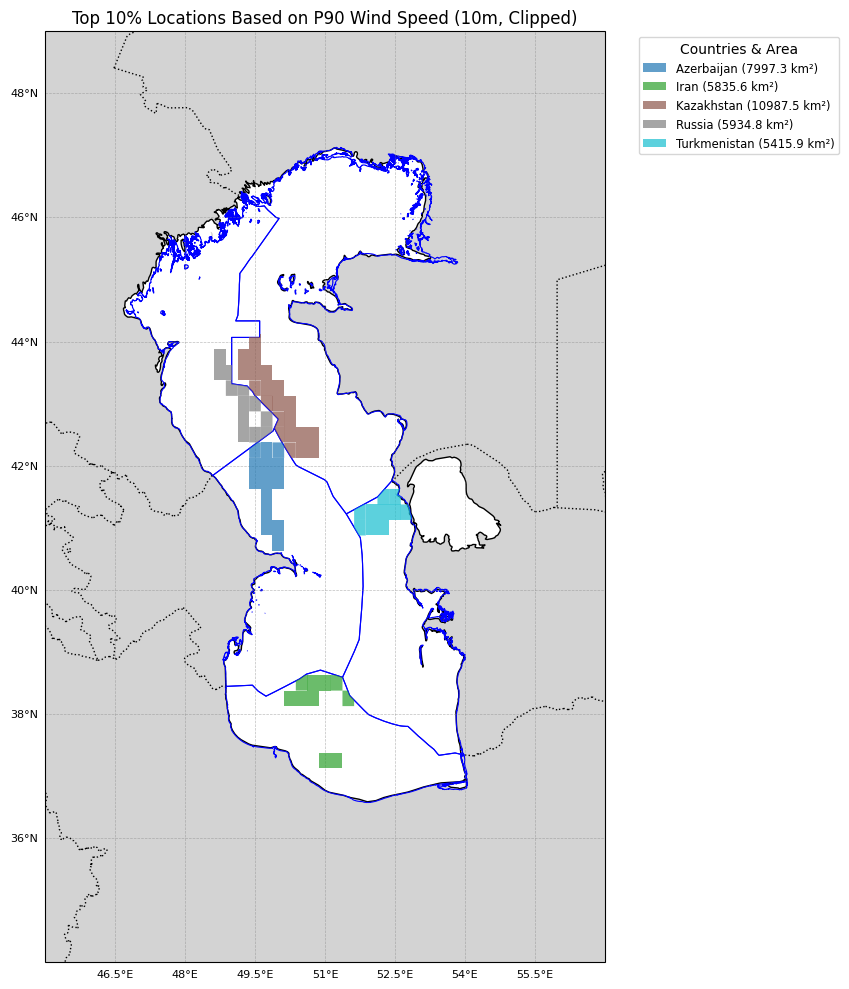

In [11]:
# === Visualize Windiest Locations (10m, Clipped Areas) ===
if 'best_area_geometries_pXX_clipped_10m' in globals():
    print(f"\nGenerating visualization of best areas (10m P{int(PERCENTILE_VALUE*100)} Speed Method, Clipped)...")
    fig_10m, ax_10m = plt.subplots(1, 1, figsize=(12, 10), subplot_kw={'projection': ccrs.PlateCarree()})
    ax_10m.set_extent(MAP_EXTENT, crs=ccrs.PlateCarree())
    ax_10m.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
    ax_10m.add_feature(cfeature.COASTLINE, zorder=1)
    ax_10m.add_feature(cfeature.BORDERS, linestyle=':', zorder=1)
    if eez_caspian is not None:
        eez_caspian.plot(ax=ax_10m, edgecolor='blue', facecolor='none', linewidth=0.8, label='Caspian EEZs', zorder=2)

    legend_handles_10m = []
    for i, country in enumerate(CASPIAN_COUNTRIES):
        gdf_to_plot = best_area_geometries_pXX_clipped_10m.get(country, None)
        country_color = COUNTRY_COLORS(i)
        country_data = results_pXX_clipped_10m.get(country, {'area_km2': 0})
        country_area = country_data['area_km2']

        if gdf_to_plot is not None and not gdf_to_plot.empty:
            gdf_to_plot.plot(ax=ax_10m, color=country_color, alpha=0.7, zorder=3)
        proxy = plt.Rectangle((0, 0), 1, 1, fc=country_color, alpha=0.7)
        legend_handles_10m.append(proxy)

    gl_10m = ax_10m.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--', zorder=4)
    gl_10m.top_labels = False; gl_10m.right_labels = False
    gl_10m.xlabel_style = {'size': 8}; gl_10m.ylabel_style = {'size': 8}
    ax_10m.set_title(f"Top {100-RANKING_PERCENTILE}% Locations Based on P{int(PERCENTILE_VALUE*100)} Wind Speed (10m, Clipped)")
    legend_labels_10m = [f"{c} ({results_pXX_clipped_10m.get(c,{}).get('area_km2',0):.1f} km²)" if results_pXX_clipped_10m.get(c,{}).get('area_km2',-1)>=0 else f"{c} (Error)" for c in CASPIAN_COUNTRIES]
    ax_10m.legend(legend_handles_10m, legend_labels_10m, title="Countries & Area", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
    plt.tight_layout(rect=[0, 0, 0.83, 1])
    plt.show()
else:
    print("Skipping 10m windiest area visualization as results are not available.")

In [12]:
# === Extract Time Series for Windiest Locations (10m) ===

windiest_10m_dataframes = {}
print("\nExtracting full time-series data for 10m windiest locations...")

if df is not None and 'results_pXX_clipped_10m' in globals():
    for country in CASPIAN_COUNTRIES:
        country_results_10m = results_pXX_clipped_10m.get(country)
        df_windiest_10m = pd.DataFrame() # Default to empty
        if country_results_10m and country_results_10m.get('coordinates'):
            windiest_coords_list_10m = country_results_10m['coordinates']
            if windiest_coords_list_10m:
                windiest_coords_set_10m = set(windiest_coords_list_10m)
                # Filter the main df for the country first
                df_country = df[df['territory'] == country].copy() # Work on a copy

                if not df_country.empty:
                    # Use temporary tuple column for efficient filtering
                    df_country['coord_tuple'] = list(zip(df_country['longitude'], df_country['latitude']))
                    df_windiest_10m = df_country[df_country['coord_tuple'].isin(windiest_coords_set_10m)].copy()
                    df_windiest_10m.drop(columns=['coord_tuple'], inplace=True, errors='ignore') # Clean up temp column
                    print(f"- {country}: Extracted {df_windiest_10m.shape[0]} rows for {len(windiest_coords_set_10m)} locations.")
                else:
                     print(f"- No original data for {country} territory.")
            else:
                 print(f"- Coordinate list empty for {country}.")
        else:
            print(f"- No coordinates found for {country}.")
        windiest_10m_dataframes[country] = df_windiest_10m

    print("\nExtraction complete for 10m.")
else:
    print("Error: Prerequisite data ('df', 10m results dictionary) not available. Skipping extraction.")


Extracting full time-series data for 10m windiest locations...
- Azerbaijan: Extracted 122976 rows for 14 locations.
- Iran: Extracted 87840 rows for 10 locations.
- Kazakhstan: Extracted 184464 rows for 21 locations.
- Russia: Extracted 105408 rows for 12 locations.
- Turkmenistan: Extracted 87840 rows for 10 locations.

Extraction complete for 10m.


In [13]:
# === Define Analysis Functions ===
# (These functions are generic)

# --- Wind Power Density Calculation Function ---
def calculate_wind_power_density(wind_speed_series):
    if not isinstance(wind_speed_series, pd.Series): wind_speed_series = pd.Series(wind_speed_series)
    wind_speed_series = wind_speed_series.dropna(); mean = np.mean(wind_speed_series)
    if wind_speed_series.empty: return None
    std_dev = np.std(wind_speed_series)
    if mean == 0: return 0.0
    if std_dev == 0 and mean > 0: return 0.5 * 1.225 * mean**3
    ratio = std_dev / mean; k = None
    if ratio == 0: return None
    try: k = max(ratio, 1e-6) ** (-1.086); k = np.clip(k, 1.0, 10.0)
    except OverflowError: k = 10.0
    try: c = mean / gamma(1 + (1 / k))
    except (ValueError, OverflowError): return None
    try: power_density = 0.5 * 1.225 * (c**3) * gamma(1 + (3 / k))
    except (ValueError, OverflowError): return None
    if not np.isfinite(power_density) or power_density < 0 or power_density > 50000: return None
    return power_density

# --- Weibull Plotting Function ---
def plot_and_get_weibull_params(wind_speed_data, plot_title_suffix, height_label='10m', hist_color='lightcoral'):
    if not isinstance(wind_speed_data, pd.Series): wind_speed_data = pd.Series(wind_speed_data)
    wind_speed_data = wind_speed_data.dropna()
    if wind_speed_data.empty: print(f"No data for {plot_title_suffix}."); return None, None
    wind_speed_data_filtered = wind_speed_data[wind_speed_data > 0.1]
    if wind_speed_data_filtered.empty: print(f"No data > 0.1 m/s for {plot_title_suffix}."); return None, None
    print(f"Fitting Weibull for {plot_title_suffix} ({len(wind_speed_data_filtered)} points)...")
    try:
        shape, loc, scale = weibull_min.fit(wind_speed_data_filtered, floc=0)
        print(f"  Params: k = {shape:.3f}, c = {scale:.3f} m/s")
        plt.figure(figsize=(10, 6))
        num_bins = min(max(int(np.sqrt(len(wind_speed_data_filtered))/2), 20), 60)
        plt.hist(wind_speed_data_filtered, bins=num_bins, density=True, alpha=0.7, color=hist_color, edgecolor='black', label='Observed Data PDF')
        x_max = wind_speed_data_filtered.quantile(0.995) if not wind_speed_data_filtered.empty else 1
        x = np.linspace(0.01, x_max, 300); pdf = weibull_min.pdf(x, shape, loc, scale)
        plt.plot(x, pdf, 'r-', lw=2.5, label='Fitted Weibull PDF')
        plt.xlabel(f'Wind Speed (m/s) at {height_label}'); plt.ylabel('Probability Density')
        plt.title(f'Wind Speed Distribution - {plot_title_suffix} ({height_label})')
        plt.legend(); plt.grid(True, alpha=0.5); plt.ylim(bottom=0); plt.xlim(left=0)
        plt.show()
        return shape, scale
    except Exception as e:
        print(f"  Error fitting/plotting Weibull for {plot_title_suffix}: {e}"); return None, None

# --- Wind Rose Plotting Function ---
def plot_wind_rose_for_region(df, u_col, v_col, region_name, height_label, cmap_to_use=plt.cm.coolwarm):
    if not all(col in df.columns for col in [u_col, v_col]): print(f"Missing {u_col}/{v_col} for {region_name} ({height_label})."); return
    df_plot = df.copy()
    speed_col = f'instant_speed_{height_label.split("m")[0]}'
    if speed_col not in df_plot.columns: df_plot[speed_col] = np.sqrt(df_plot[u_col]**2 + df_plot[v_col]**2)
    direction_rad = np.arctan2(df_plot[v_col], df_plot[u_col]); direction_deg = np.degrees(direction_rad)
    df_plot['wind_direction'] = (direction_deg + 360) % 360
    df_plot.dropna(subset=['wind_direction', speed_col], inplace=True)
    if df_plot.empty: print(f"No valid direction/speed data for {region_name} ({height_label})."); return
    print(f"  Generating plot for {len(df_plot)} data points...")
    fig = plt.figure(figsize=(9, 9)); rect = [0.1, 0.1, 0.8, 0.8]; ax = WindroseAxes(fig, rect); fig.add_axes(ax)
    max_speed = df_plot[speed_col].quantile(0.99); spd_bins = np.linspace(0, max(max_speed, 5), 6)
    ax.bar(df_plot['wind_direction'], df_plot[speed_col], bins=spd_bins, nsector=16, normed=True, opening=0.8, edgecolor='white', cmap=cmap_to_use)
    ax.set_legend(title='Wind Speed (m/s)', loc='center left', bbox_to_anchor=(1.1, 0.5), fontsize='medium')
    ax.set_title(f"Wind Rose for {region_name} Windiest Region ({height_label})", y=1.05, fontsize=14)
    current_yticks = ax.get_yticks()
    if len(current_yticks) > 1: tick_step = max(round(current_yticks[1] / 2), 2); ax.set_yticks(np.arange(0, current_yticks.max() + tick_step, tick_step)); ax.set_yticklabels([f'{y:.0f}%' for y in ax.get_yticks()])
    plt.show()

print("Analysis functions defined.")

Analysis functions defined.


In [14]:
# === Calculate WPD for Windiest Regions (10m) ===

wpd_windiest_10m = {}

if 'windiest_10m_dataframes' in globals():
    print("\nCalculating Wind Power Density for Windiest Regions (10m)...")
    for country in CASPIAN_COUNTRIES:
        print(f"- Processing {country}...")
        df_windy = windiest_10m_dataframes.get(country)
        wpd = None
        if df_windy is not None and not df_windy.empty:
             # Ensure speed column exists, calculate if needed
             if 'instant_speed_10' not in df_windy.columns:
                 if 'u10' in df_windy.columns and 'v10' in df_windy.columns:
                     print("  Calculating 'instant_speed_10'...")
                     df_windy['instant_speed_10'] = np.sqrt(df_windy['u10']**2 + df_windy['v10']**2)
                 else:
                     print("  Skipping WPD calc, 'instant_speed_10' or components missing.")
                     wpd = None
                     wpd_windiest_10m[country] = wpd
                     continue
             # Proceed if column exists or was calculated
             if 'instant_speed_10' in df_windy.columns:
                  wpd = calculate_wind_power_density(df_windy['instant_speed_10'])
             else:
                  wpd = None
        else:
             print("  No data.")
        wpd_windiest_10m[country] = wpd

    # --- Print WPD Results ---
    print("\n--- Wind Power Density for Windiest Regions (W/m²) ---")
    print("\nBased on 10m wind data:")
    for country, density in wpd_windiest_10m.items():
        print(f"- {country}: {density:.2f} W/m²" if density is not None else f"- {country}: Could not calculate WPD")

else:
    print("Error: Windiest 10m dataframes not available. Skipping WPD calculation.")


Calculating Wind Power Density for Windiest Regions (10m)...
- Processing Azerbaijan...
- Processing Iran...
- Processing Kazakhstan...
- Processing Russia...
- Processing Turkmenistan...

--- Wind Power Density for Windiest Regions (W/m²) ---

Based on 10m wind data:
- Azerbaijan: 275.05 W/m²
- Iran: 99.79 W/m²
- Kazakhstan: 284.75 W/m²
- Russia: 289.08 W/m²
- Turkmenistan: 229.36 W/m²



--- Generating Weibull Plots for Windiest Regions (10m) ---

Processing Azerbaijan (10m)...
Fitting Weibull for Azerbaijan Windiest Region (122949 points)...
  Params: k = 1.964, c = 6.944 m/s


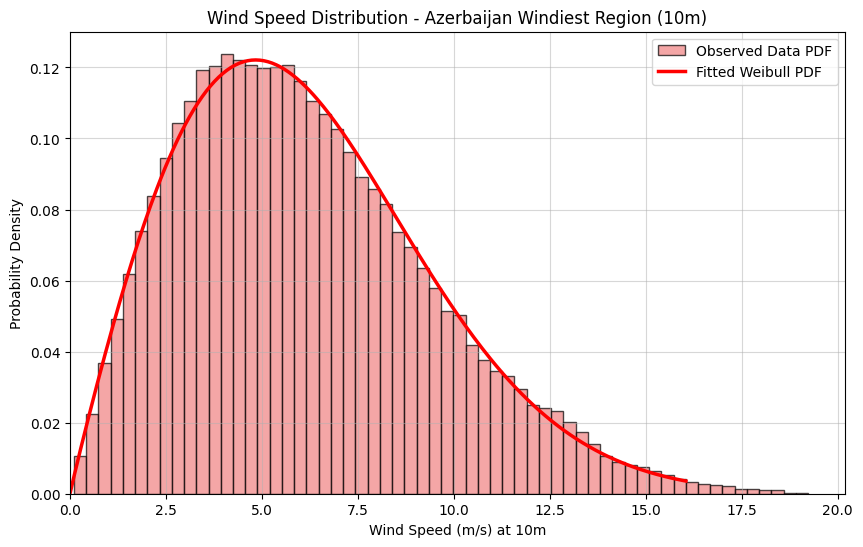


Processing Iran (10m)...
Fitting Weibull for Iran Windiest Region (87806 points)...
  Params: k = 1.961, c = 4.948 m/s


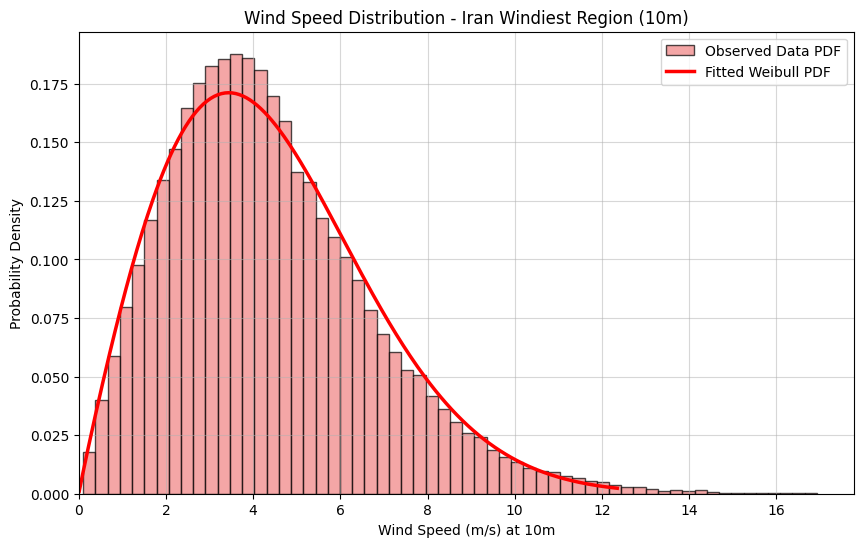


Processing Kazakhstan (10m)...
Fitting Weibull for Kazakhstan Windiest Region (184433 points)...
  Params: k = 2.090, c = 7.174 m/s


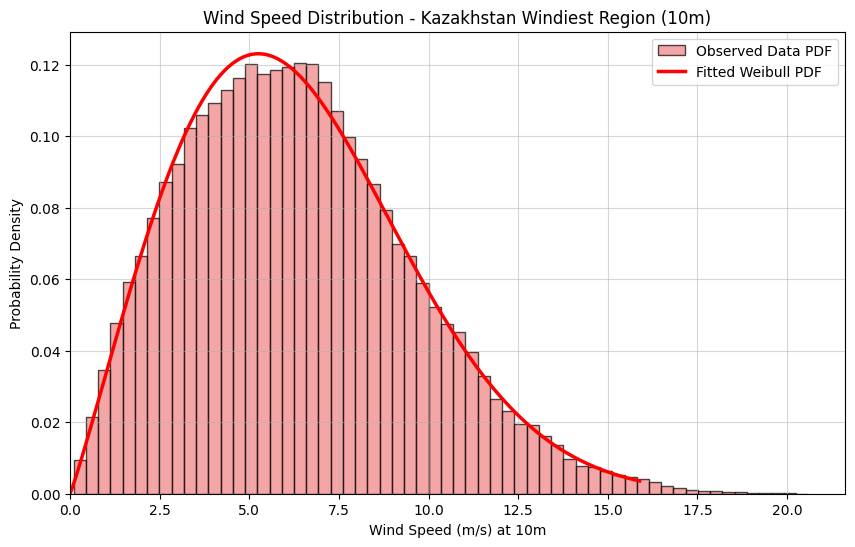


Processing Russia (10m)...
Fitting Weibull for Russia Windiest Region (105387 points)...
  Params: k = 2.027, c = 7.140 m/s


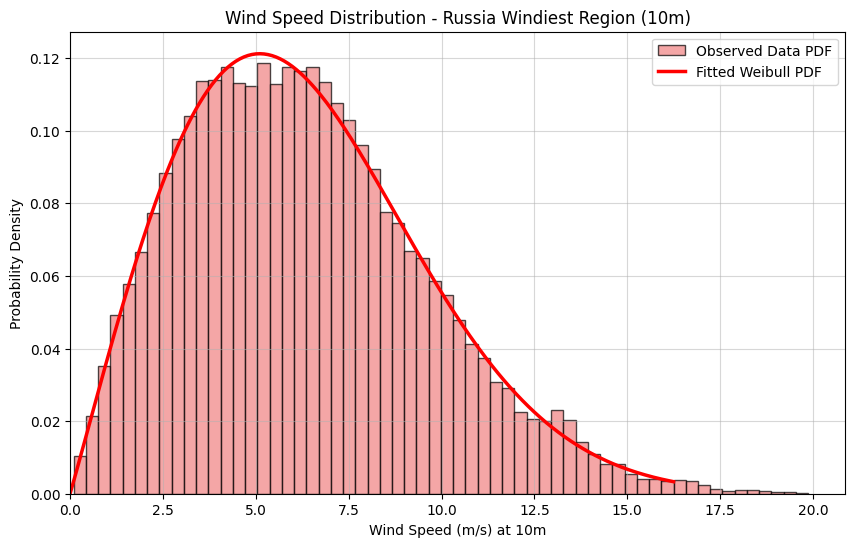


Processing Turkmenistan (10m)...
Fitting Weibull for Turkmenistan Windiest Region (87832 points)...
  Params: k = 2.345, c = 6.886 m/s


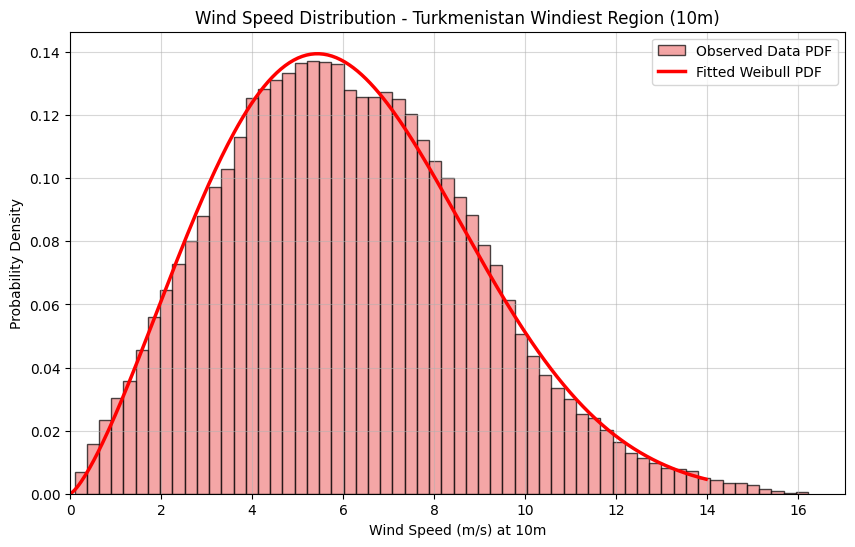


--- Summary of Fitted Weibull Parameters for Windiest Regions (10m) ---
Country         | Shape (k) | Scale (c) [m/s]
----------------|-----------|-----------------
Azerbaijan      |     1.964 |           6.944
Iran            |     1.961 |           4.948
Kazakhstan      |     2.090 |           7.174
Russia          |     2.027 |           7.140
Turkmenistan    |     2.345 |           6.886


In [15]:
# === Weibull Analysis for Windiest Regions (10m) ===

weibull_params_10m = {}

if 'windiest_10m_dataframes' in globals():
    print("\n--- Generating Weibull Plots for Windiest Regions (10m) ---")
    for country in CASPIAN_COUNTRIES:
        print(f"\nProcessing {country} (10m)...")
        df_windy = windiest_10m_dataframes.get(country)
        k, c = None, None
        if df_windy is not None and not df_windy.empty:
            # Ensure speed column exists, calculate if needed
            if 'instant_speed_10' not in df_windy.columns:
                if 'u10' in df_windy.columns and 'v10' in df_windy.columns:
                    print("  Calculating 'instant_speed_10'...")
                    df_windy['instant_speed_10'] = np.sqrt(df_windy['u10']**2 + df_windy['v10']**2)
                else:
                    print("  Skipping Weibull, 'instant_speed_10' or components missing.")
                    weibull_params_10m[country] = {'k': None, 'c': None}
                    continue
            # Proceed if column exists or was calculated
            if 'instant_speed_10' in df_windy.columns:
                speed_series = df_windy['instant_speed_10']
                title = f"{country} Windiest Region"
                k, c = plot_and_get_weibull_params(speed_series, title, height_label='10m', hist_color=COLOR_10M)
            else:
                 k, c = None, None
        else:
            print("  No data.")
        weibull_params_10m[country] = {'k': k, 'c': c}

    # --- Print Summary of Parameters ---
    print("\n--- Summary of Fitted Weibull Parameters for Windiest Regions (10m) ---")
    print("Country         | Shape (k) | Scale (c) [m/s]")
    print("----------------|-----------|-----------------")
    for country, params in weibull_params_10m.items():
        k_str = f"{params['k']:.3f}" if params.get('k') is not None else "N/A"
        c_str = f"{params['c']:.3f}" if params.get('c') is not None else "N/A"
        print(f"{country:<15} | {k_str:>9} | {c_str:>15}")

else:
    print("Error: Windiest 10m dataframes not available. Skipping Weibull analysis.")


--- Generating Wind Roses for Windiest Regions (10m) ---

Plotting 10m Wind Rose for Azerbaijan Windiest Region...
  Generating plot for 122976 data points...


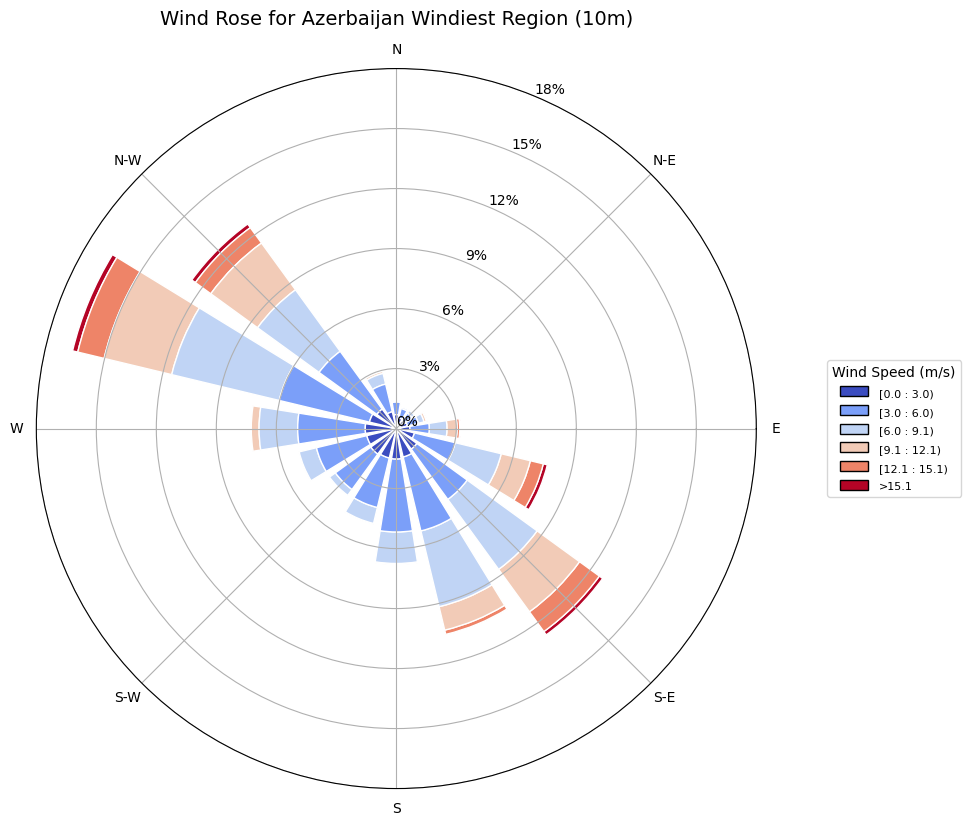


Plotting 10m Wind Rose for Iran Windiest Region...
  Generating plot for 87840 data points...


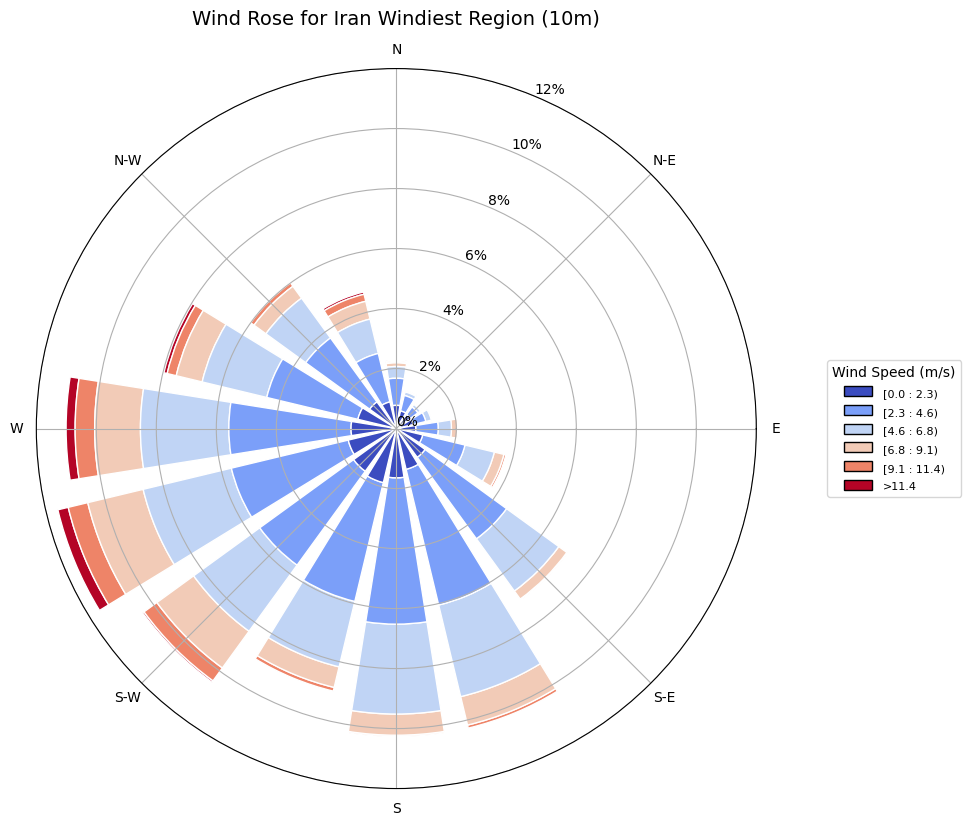


Plotting 10m Wind Rose for Kazakhstan Windiest Region...
  Generating plot for 184464 data points...


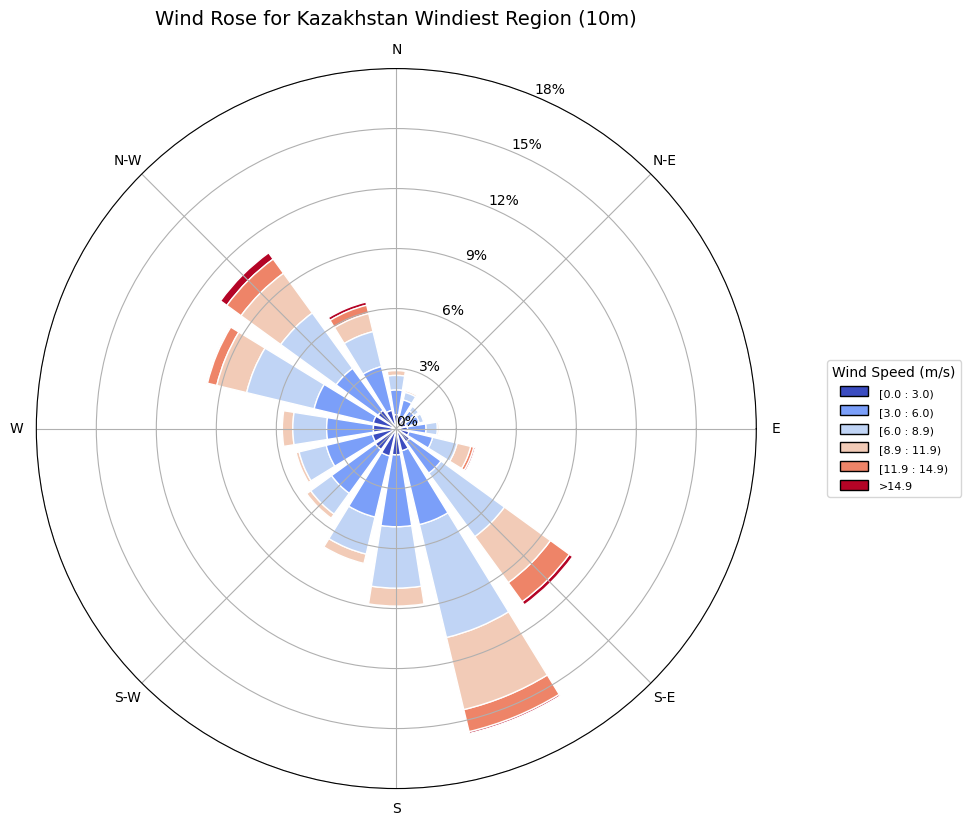


Plotting 10m Wind Rose for Russia Windiest Region...
  Generating plot for 105408 data points...


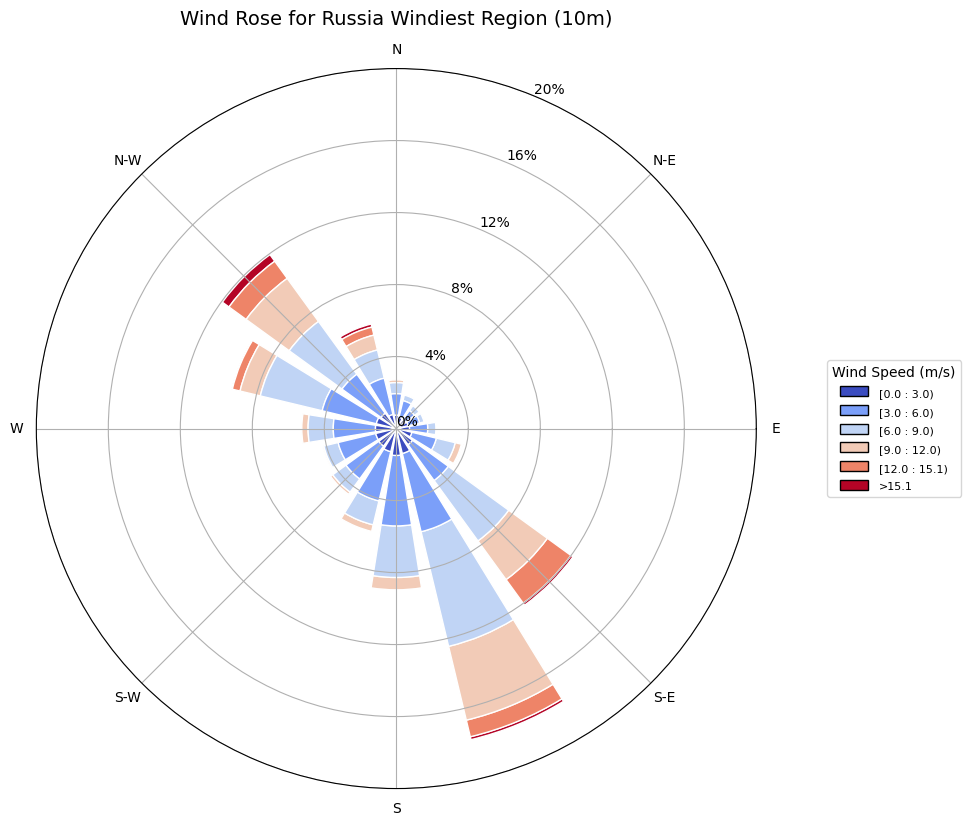


Plotting 10m Wind Rose for Turkmenistan Windiest Region...
  Generating plot for 87840 data points...


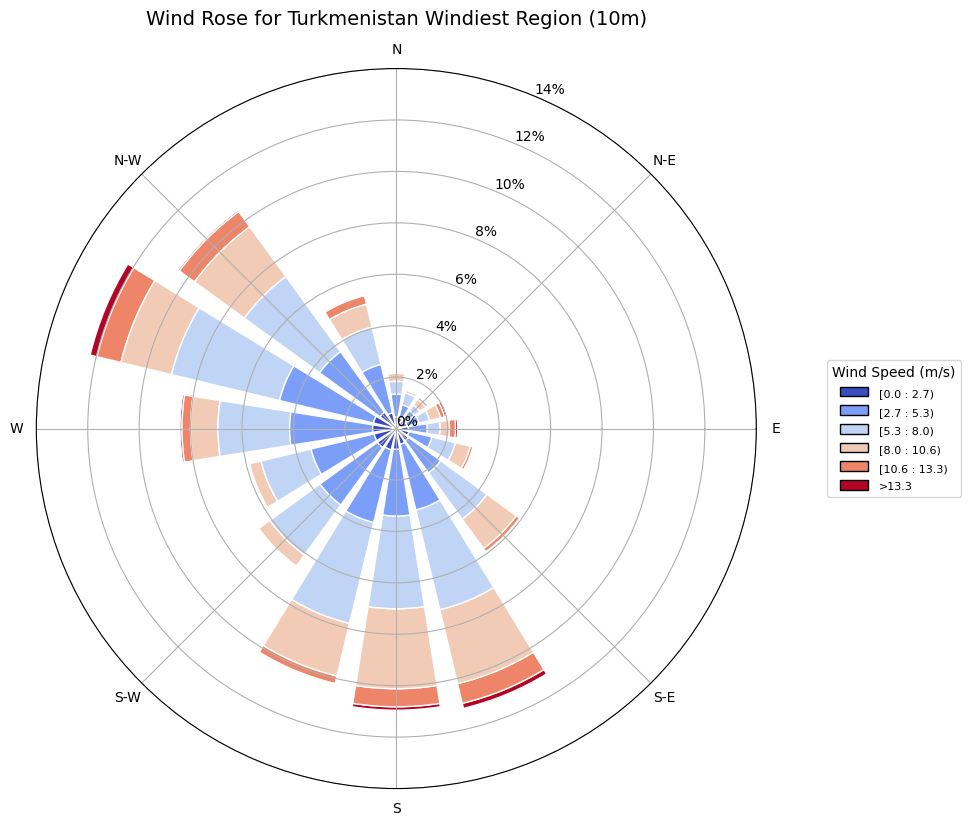

In [16]:
# === Wind Rose Analysis for Windiest Regions (10m) ===

if 'windiest_10m_dataframes' in globals():
    print("\n--- Generating Wind Roses for Windiest Regions (10m) ---")
    for country in CASPIAN_COUNTRIES:
        print(f"\nPlotting 10m Wind Rose for {country} Windiest Region...")
        df_windy = windiest_10m_dataframes.get(country)
        if df_windy is None or df_windy.empty:
            print(f"  Skipping {country}, no data.")
            continue
        # Check if u10/v10 exist
        if not all(col in df_windy.columns for col in ['u10', 'v10']):
            print(f"  Skipping {country}, missing u10 or v10 columns.")
            continue
        plot_wind_rose_for_region(df_windy, 'u10', 'v10', country, '10m', cmap_to_use=CMAP_10M)
else:
    print("Error: Windiest 10m dataframes not available. Skipping Wind Rose analysis.")

In [17]:
# === Final Summary DataFrame & Coordinate List (10m Analysis) ===

import pandas as pd
import numpy as np
from IPython.display import display

print("\nConsolidating final numerical results for 10m windiest regions...")

# --- Check prerequisites ---
required_results_check = ['results_pXX_clipped_10m', 'wpd_windiest_10m', 'weibull_params_10m', 'CASPIAN_COUNTRIES']
final_summary_10m_df = pd.DataFrame() # Initialize empty

if not all(res in globals() for res in required_results_check):
    print("Error: One or more necessary 10m result dictionaries/variables are missing. Cannot create final summary.")
else:
    final_summary_data_10m = {}
    for country in CASPIAN_COUNTRIES:
        area_data = results_pXX_clipped_10m.get(country, {'area_km2': np.nan, 'coordinates': []})
        wpd_value = wpd_windiest_10m.get(country, np.nan)
        weibull_data = weibull_params_10m.get(country, {'k': np.nan, 'c': np.nan})
        area_km2 = area_data['area_km2']
        if isinstance(area_km2, str) and area_km2 == 'Error': area_km2 = np.nan

        final_summary_data_10m[country] = {
            'Area (km²)': area_km2,
            'Num Locations': len(area_data.get('coordinates', [])),
            'WPD (W/m²)': wpd_value,
            'Weibull k': weibull_data.get('k'),
            'Weibull c (m/s)': weibull_data.get('c')
        }

    final_summary_10m_df = pd.DataFrame.from_dict(final_summary_data_10m, orient='index')
    final_summary_10m_df.index.name = 'Country'

    # Round numeric columns
    numeric_cols = ['Area (km²)', 'WPD (W/m²)', 'Weibull k', 'Weibull c (m/s)']
    for col in numeric_cols:
        if col in final_summary_10m_df.columns:
             final_summary_10m_df[col] = pd.to_numeric(final_summary_10m_df[col], errors='coerce')
             decimals = 2 if 'Area' in col or 'WPD' in col else 3
             final_summary_10m_df[col] = final_summary_10m_df[col].round(decimals)

    print("\n--- Final Summary Table (10m Windiest Regions) ---")
    display(final_summary_10m_df)

# --- Print All Stored Coordinates for Windiest Locations (10m) ---
print("\n" + "="*50)
print("--- Coordinates List for Windiest Locations (10m) ---")
print("="*50)

if 'results_pXX_clipped_10m' in globals():
    all_coords_found = False
    for country in CASPIAN_COUNTRIES:
        print(f"\nCoordinates for: {country}")
        country_results = results_pXX_clipped_10m.get(country, {})
        coords_list = country_results.get('coordinates', [])

        if coords_list:
            all_coords_found = True
            num_coords = len(coords_list)
            print(f"  Found {num_coords} coordinate pair(s) (Lon, Lat):")
            MAX_COORDS_TO_PRINT = 100
            coords_to_print = coords_list[:MAX_COORDS_TO_PRINT]
            for i, coord in enumerate(coords_to_print): print(f"    {i+1}: ({coord[0]:.4f}, {coord[1]:.4f})")
            if num_coords > MAX_COORDS_TO_PRINT: print(f"    ... (displaying first {MAX_COORDS_TO_PRINT} out of {num_coords})")
        else:
            print("  No coordinates were stored or found for this country.")
        print("-" * 30)
    if not all_coords_found: print("\nNo coordinates were found stored in the results dictionary for any country.")
else:
    print("\nResults dictionary 'results_pXX_clipped_10m' not found, cannot print coordinates.")


Consolidating final numerical results for 10m windiest regions...

--- Final Summary Table (10m Windiest Regions) ---


,Area (km²),Num Locations,WPD (W/m²),Weibull k,Weibull c (m/s)
Country,,,,,
Azerbaijan,7997.30,14,275.049988,1.964,6.944
Iran,5835.63,10,99.790001,1.961,4.948
Kazakhstan,10987.53,21,284.750000,2.090,7.174
Russia,5934.81,12,289.079987,2.027,7.140
Turkmenistan,5415.90,10,229.360001,2.345,6.886



--- Coordinates List for Windiest Locations (10m) ---

Coordinates for: Azerbaijan
  Found 14 coordinate pair(s) (Lon, Lat):
    1: (49.5000, 41.7500)
    2: (49.5000, 42.0000)
    3: (49.5000, 42.2500)
    4: (49.7500, 41.0000)
    5: (49.7500, 41.2500)
    6: (49.7500, 41.5000)
    7: (49.7500, 41.7500)
    8: (49.7500, 42.0000)
    9: (49.7500, 42.2500)
    10: (50.0000, 40.7500)
    11: (50.0000, 41.0000)
    12: (50.0000, 41.7500)
    13: (50.0000, 42.0000)
    14: (50.0000, 42.2500)
------------------------------

Coordinates for: Iran
  Found 10 coordinate pair(s) (Lon, Lat):
    1: (50.2500, 38.2500)
    2: (50.5000, 38.2500)
    3: (50.5000, 38.5000)
    4: (50.7500, 38.2500)
    5: (50.7500, 38.5000)
    6: (51.0000, 37.2500)
    7: (51.0000, 38.5000)
    8: (51.2500, 37.2500)
    9: (51.2500, 38.5000)
    10: (51.5000, 38.2500)
------------------------------

Coordinates for: Kazakhstan
  Found 21 coordinate pair(s) (Lon, Lat):
    1: (49.2500, 43.5000)
    2: (49.2500, 43.